In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
tips = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv')
tips['tip_pct'] = (tips['tip'] / tips['total_bill'] * 100).round(1)
print(f"tips: {tips.shape[0]} wierszy, {tips.shape[1]} kolumn")

tips: 244 wierszy, 8 kolumn


In [2]:
#dane do lotnisk
lotniska = pd.DataFrame({
    'miasto': ['Warszawa', 'Kraków', 'Gdańsk', 'Wrocław', 'Katowice',
               'Poznań', 'Rzeszów', 'Łódź', 'Szczecin', 'Bydgoszcz'],
    'kod': ['WAW', 'KRK', 'GDN', 'WRO', 'KTW',
            'POZ', 'RZE', 'LCJ', 'SZZ', 'BZG'],
    'pasazerowie_mln': [18.9, 9.3, 5.7, 3.8, 5.4,
                        2.6, 0.9, 0.3, 0.6, 0.4],
    'linie': [85, 42, 35, 28, 32, 22, 12, 5, 8, 6],
    'region': ['Mazowieckie', 'Małopolskie', 'Pomorskie', 'Dolnośląskie', 'Śląskie',
               'Wielkopolskie', 'Podkarpackie', 'Łódzkie', 'Zachodniopomorskie', 'Kujawsko-Pomorskie']
})
lotniska.index = lotniska['kod']

#1a
print("1a.1: Pierwsze 3 lotniska:\n", lotniska.iloc[:3])
print("\n1a.2: Lotniska 5-8 (kolumny 0 i 2):\n", lotniska.iloc[4:8, [0, 2]])

# 1b
print("\n1b.1: Dane lotniska KRK:\n", lotniska.loc['KRK'])
print("\n1b.3: Lotniska > 5 mln pasażerów:\n", lotniska.loc[lotniska['pasazerowie_mln'] > 5])

# 1c
reg_m = lotniska.loc[lotniska['region'].str.startswith('M')]
print(f"\n1c.1: Liczba lotnisk w regionach na 'M': {len(reg_m)}")

lotniska['oblozenie'] = (lotniska['pasazerowie_mln'] / lotniska['linie'] * 1000000)
print("\n1c.2: TOP 3 obłożenie:\n", lotniska.nlargest(3, 'oblozenie'))

1a.1: Pierwsze 3 lotniska:
        miasto  kod  pasazerowie_mln  linie       region
kod                                                    
WAW  Warszawa  WAW             18.9     85  Mazowieckie
KRK    Kraków  KRK              9.3     42  Małopolskie
GDN    Gdańsk  GDN              5.7     35    Pomorskie

1a.2: Lotniska 5-8 (kolumny 0 i 2):
        miasto  pasazerowie_mln
kod                           
KTW  Katowice              5.4
POZ    Poznań              2.6
RZE   Rzeszów              0.9
LCJ      Łódź              0.3

1b.1: Dane lotniska KRK:
 miasto                  Kraków
kod                        KRK
pasazerowie_mln            9.3
linie                       42
region             Małopolskie
Name: KRK, dtype: object

1b.3: Lotniska > 5 mln pasażerów:
        miasto  kod  pasazerowie_mln  linie       region
kod                                                    
WAW  Warszawa  WAW             18.9     85  Mazowieckie
KRK    Kraków  KRK              9.3     42  Małopolskie
G

In [3]:
#runda1 kod
print(f"Rachunki w piątek: {len(tips[tips['day'] == 'Fri'])}")
print(f"Max rachunek kobiety: {tips[tips['sex'] == 'Female']['total_bill'].max()}$")

#2 kod
weekend = ['Sat', 'Sun']
niepalacy_mez_obiad = tips[(tips['sex'] == 'Male') & (tips['smoker'] == 'No') & 
                           (tips['time'] == 'Dinner') & (tips['day'].isin(weekend))]
print(f"Niepalący mężczyźni (obiad, weekend): {len(niepalacy_mez_obiad)}")

#3 kod
srednia = tips['total_bill'].mean()
hojni_query = tips.query('total_bill < 10 and tip_pct > 25')
print("\nPodejrzanie hojni (query):\n", hojni_query)

Rachunki w piątek: 19
Max rachunek kobiety: 44.3$
Niepalący mężczyźni (obiad, weekend): 75

Podejrzanie hojni (query):
      total_bill   tip     sex smoker   day    time  size  tip_pct
67         3.07  1.00  Female    Yes   Sat  Dinner     1     32.6
149        7.51  2.00    Male     No  Thur   Lunch     2     26.6
172        7.25  5.15    Male    Yes   Sun  Dinner     2     71.0
178        9.60  4.00  Female    Yes   Sun  Dinner     2     41.7


In [4]:
filmy = pd.DataFrame({
    'tytul': ['Incepcja', 'Parasite', 'Avengers: Endgame', 'Joker', 'Coco',
              'Get Out', 'Dune', 'Whiplash', 'Mad Max: Fury Road', 'Spider-Man: No Way Home',
              'The Batman', 'Everything Everywhere', 'Oppenheimer', 'Barbie', 'La La Land',
              'Blade Runner 2049', 'Knives Out', '1917', 'Jojo Rabbit', 'Midsommar'],
    'rok': [2010, 2019, 2019, 2019, 2017, 2017, 2021, 2014, 2015, 2021, 2022, 2022, 2023, 2023, 2016, 2017, 2019, 2019, 2019, 2019],
    'gatunek': ['Sci-Fi', 'Thriller', 'Akcja', 'Dramat', 'Animacja', 'Horror', 'Sci-Fi', 'Dramat', 'Akcja', 'Akcja', 'Akcja', 'Sci-Fi', 'Dramat', 'Komedia', 'Musical', 'Sci-Fi', 'Kryminał', 'Wojenny', 'Komedia', 'Horror'],
    'budzet_mln': [160, 11, 356, 55, 175, 4.5, 165, 3.3, 150, 200, 185, 25, 100, 145, 30, 150, 40, 95, 14, 9],
    'przychod_mln': [836, 258, 2798, 1074, 807, 255, 407, 49, 380, 1916, 771, 141, 952, 1442, 447, 259, 311, 384, 90, 48],
    'ocena_imdb': [8.8, 8.5, 8.4, 8.4, 8.4, 7.7, 8.0, 8.5, 8.1, 8.2, 7.8, 7.8, 8.3, 6.8, 8.0, 8.0, 7.9, 8.3, 7.9, 7.1]
})
filmy['roi'] = (filmy['przychod_mln'] / filmy['budzet_mln']).round(1)

# 3a
print("TOP 5 pod względem ROI:\n", filmy.nlargest(5, 'roi')[['tytul', 'roi']])

# 3c
wynik = (filmy
    [filmy['ocena_imdb'] >= 7.5]
    .nlargest(3, 'roi')
    [['tytul', 'gatunek', 'roi', 'ocena_imdb']]
)
print("\nTOP 3 ROI (Ocena >= 7.5):\n", wynik)

TOP 5 pod względem ROI:
          tytul   roi
5      Get Out  56.7
1     Parasite  23.5
3        Joker  19.5
14  La La Land  14.9
7     Whiplash  14.8

TOP 3 ROI (Ocena >= 7.5):
       tytul   gatunek   roi  ocena_imdb
5   Get Out    Horror  56.7         7.7
1  Parasite  Thriller  23.5         8.5
3     Joker    Dramat  19.5         8.4


Liczba filmów w segmentach:
 segment
Zyskowny      12
Hit            5
Przeciętny     3
Name: count, dtype: int64


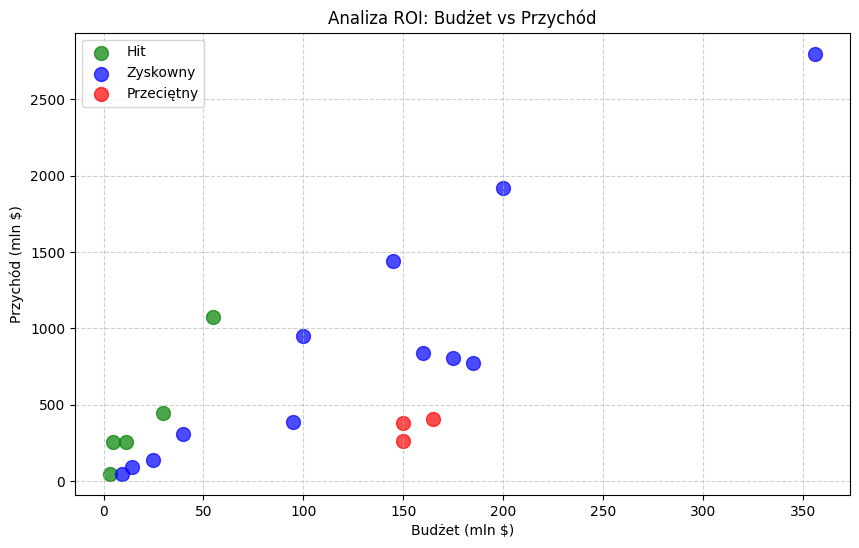

In [5]:
# 4a sSegmentacja
filmy['segment'] = np.select(
    [filmy['roi'] > 10, filmy['roi'] > 3],
    ['Hit', 'Zyskowny'],
    default='Przeciętny'
)

print("Liczba filmów w segmentach:\n", filmy['segment'].value_counts())

# 4b wizualizacja
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
kolory = {'Hit': 'green', 'Zyskowny': 'blue', 'Przeciętny': 'red'}

for seg, kolor in kolory.items():
    dane = filmy[filmy['segment'] == seg]
    ax.scatter(dane['budzet_mln'], dane['przychod_mln'], 
               c=kolor, label=seg, s=100, alpha=0.7)

ax.set_xlabel('Budżet (mln $)')
ax.set_ylabel('Przychód (mln $)')
ax.set_title('Analiza ROI: Budżet vs Przychód')
ax.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
